# Case 1, dt=0.05

In [1]:
# IMPORTS
import os
import time
import psutil
import random
import warnings
import csv

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve
from scipy.optimize import minimize

tf.config.set_visible_devices([], 'GPU')

# CONFIG
TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam
EPOCHS      = 1200
LR          = 2e-5

SUP_WEIGHT  = 0.0
PHYS_WEIGHT = 0.1 / DT

BETA_L2   = 1e-6
GRAD_CLIP = 0.5
PATIENCE  = 800

# L-BFGS
USE_LBFGS     = True
LBFGS_MAXITER = 300
LBFGS_FTOL    = 1e-10

# Output Paths
CASE_NAME = "CaseB_PhysicsOnly"

OUT_DIR = f"{CASE_NAME}_results"

os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly_meta.npz"
)

DATA_FILE = os.path.join(
    OUT_DIR,
    "training_pairs.npz"
)

METRICS_FILE = os.path.join(
    OUT_DIR,
    "timing_metrics.csv"
)

# Reproducibility
if TF64:

    tf.keras.backend.set_floatx("float64")

np.random.seed(42)

tf.random.set_seed(42)

random.seed(42)

warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

tf.get_logger().setLevel("ERROR")

# Memory utilities
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

print("\nCONFIG LOADED")

print("Initial memory usage: %.2f MB" % memory_mb())

# Spectral differentiation
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(
    D_np,
    dtype=tf.float64
)

# Residual
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(
        y_sq,
        tf.transpose(D_tf)
    )

    return y - u + 0.25 * DT * dy_dx

# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Fourier interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2

    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(
        un,
        dtype=np.float64
    )

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol, info, ier, msg = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12,
        maxfev=30000,
        full_output=True
    )

    if ier != 1:

        print("[warn fsolve]", msg)

    return y_sol.astype(np.float64)

# Training functions
def make_rich_family():

    fns = []
    # Fourier modes
    for k in range(1, 13):

        fns.append((
            f"sin({k}x)",
            lambda x, kk=k: np.sin(kk*x)
        ))

        fns.append((
            f"cos({k}x)",
            lambda x, kk=k: np.cos(kk*x)
        ))

    # Phase shifted
    for k in range(1, 6):

        for phi in [0.3, 0.7, 1.2]:

            fns.append((
                f"sin({k}x+{phi})",
                lambda x, kk=k, pp=phi:
                    np.sin(kk*x + pp)
            ))

    # Fractional frequencies
    for k in [1.5, 2.5, 3.5, 4.5]:

        fns.append((
            f"sin({k}x)",
            lambda x, kk=k: np.sin(kk*x)
        ))

    # Polynomial nonlinearities
    fns += [

        (
            "sin^2(x)",
            lambda x: np.sin(x)**2
        ),

        (
            "cos^2(x)",
            lambda x: np.cos(x)**2
        ),

        (
            "sin^3(x)",
            lambda x: np.sin(x)**3
        ),

        (
            "cos^3(x)",
            lambda x: np.cos(x)**3
        )
    ]

    # Mixed modes
    fns += [

        (
            "sin+0.5sin2",
            lambda x: np.sin(x)+0.5*np.sin(2*x)
        ),

        (
            "cos+0.5cos2",
            lambda x: np.cos(x)+0.5*np.cos(2*x)
        ),

        (
            "sin2+cos3",
            lambda x: np.sin(2*x)+np.cos(3*x)
        ),

        (
            "sin3+cos5",
            lambda x: np.sin(3*x)+0.7*np.cos(5*x)
        ),

        (
            "sin5+sin7",
            lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)
        ),

        (
            "cos4+cos8",
            lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)
        )
    ]

    # Gaussian-localized
    fns += [

        (
            "gauss*sin(5x)",
            lambda x:
                np.exp(-(x-np.pi)**2)
                * np.sin(5*x)
        ),

        (
            "gauss*sin(10x)",
            lambda x:
                np.exp(-(x-np.pi)**2)
                * np.sin(10*x)
        ),

        (
            "gauss*cos(7x)",
            lambda x:
                np.exp(-0.5*(x-np.pi)**2)
                * np.cos(7*x)
        )
    ]

    # Exponentials
    fns += [

        (
            "exp(-x)sin(x)",
            lambda x:
                np.exp(-0.2*x)*np.sin(x)
        ),

        (
            "exp(-x)cos(3x)",
            lambda x:
                np.exp(-0.4*x)*np.cos(3*x)
        )
    ]
    # Random combo
    rng = np.random.default_rng(123)

    for idx in range(30):

        ks = rng.integers(
            1,
            13,
            size=3
        )

        a = rng.uniform(
            -1.0,
            1.0,
            size=3
        )

        b = rng.uniform(
            -1.0,
            1.0,
            size=3
        )

        def make_fn(
            ks=ks,
            a=a,
            b=b
        ):

            return lambda x, ks=ks, a=a, b=b: (

                a[0]*np.sin(ks[0]*x)

                + a[1]*np.cos(ks[1]*x)

                + a[2]*np.sin(ks[2]*x)

                + b[0]*np.cos(ks[0]*x)

                + b[1]*np.sin(ks[1]*x)

                + b[2]*np.cos(ks[2]*x)
            )

        fns.append((
            f"rand_combo_{idx}",
            make_fn()
        ))

    return fns

train_fns = make_rich_family()

print(
    "Training family size:",
    len(train_fns)
)

# Generate / Load data
if os.path.exists(DATA_FILE):

    dd = np.load(
        DATA_FILE,
        allow_pickle=True
    )

    un_train = dd["un"]

    y1_train = dd["y1"]

    print(
        "Loaded cached data:",
        un_train.shape
    )

else:

    print("\nGenerating fsolve training data...")

    U_list = []

    Y_list = []

    for i, (name, fn) in enumerate(train_fns):

        u_c = fn(x_coarse)

        u_f = fourier_interpolate(
            u_c,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(u_f)

        U_list.append(u_f)

        Y_list.append(y1)

        print(
            f"{i+1}/{len(train_fns)} -> {name}"
        )

    un_train = np.array(U_list)

    y1_train = np.array(Y_list)

    np.savez(
        DATA_FILE,
        un=un_train,
        y1=y1_train
    )

# FEATURES
def build_features(un_batch):

    mag = np.abs(
        np.fft.fft(
            un_batch,
            axis=-1
        )
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate(
        [un_batch, mag],
        axis=-1
    )

X_raw = build_features(un_train)

feat_mean = np.mean(
    X_raw,
    axis=0
)

feat_std = np.std(
    X_raw,
    axis=0
) + 1e-12

X_norm = (
    X_raw - feat_mean
) / feat_std

print(
    "\nFeature shape:",
    X_norm.shape
)

# SIREN LAYER
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0 / in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Mpdel
def build_model():

    input_dim = X_norm.shape[1]

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(
        inputs,
        outputs
    )

model = build_model()

_ = model(
    tf.zeros(
        (1, X_norm.shape[1]),
        dtype=tf.float64
    )
)

print(
    model.count_params(),
    "parameters"
)

# Into tensors
X_tf = tf.convert_to_tensor(
    X_norm,
    dtype=tf.float64
)

U_tf = tf.convert_to_tensor(
    un_train,
    dtype=tf.float64
)

optimizer = tf.keras.optimizers.Adam(LR)

# Training
print("\nSTART TRAINING")

train_start = time.perf_counter()

peak_memory_before = memory_mb()

best_total = np.inf

wait = 0

for epoch in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y_pred = model(
            X_tf,
            training=True
        )
        # Phy loss only
        r = residual_tf(
            y_pred,
            U_tf
        )

        phys_loss = tf.reduce_mean(
            tf.square(r)
        )

        reg = BETA_L2 * tf.add_n([

            tf.nn.l2_loss(v)

            for v in model.trainable_variables
        ])

        total = (
            PHYS_WEIGHT * phys_loss
            + reg
        )

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [

        tf.clip_by_norm(g, GRAD_CLIP)

        for g in grads
    ]

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if epoch % 100 == 0 or epoch == 1:

        print(

            f"Epoch {epoch:4d} | "

            f"Total={float(total):.3e} | "

            f"Phys={float(phys_loss):.3e}"
        )

    total_val = float(total.numpy())

    if total_val < best_total:

        best_total = total_val

        wait = 0

        model.save_weights(
            WEIGHTS_FILE
        )

    else:

        wait += 1

        if wait >= PATIENCE:

            print("Early stopping.")

            break

train_end = time.perf_counter()

train_time_sec = (
    train_end - train_start
)

peak_memory_after = memory_mb()

peak_memory_used = (
    peak_memory_after
    - peak_memory_before
)

print("\nTRAINING COMPLETE")

print(
    "Training time: %.2f sec"
    % train_time_sec
)

print(
    "Memory increase: %.2f MB"
    % peak_memory_used
)

# L-BFGS polish
if USE_LBFGS:

    print(
        "\n=== PHASE 2: L-BFGS polish "
        "(physics-only loss) ==="
    )
    # reload best Adam weights
    model.load_weights(
        WEIGHTS_FILE
    )

    print(
        "[L-BFGS] loaded best Adam weights"
    )
    # parameter
    var_list = model.trainable_variables

    shapes = [v.shape for v in var_list]

    sizes = [
        int(np.prod(s))
        for s in shapes
    ]

    total_params = sum(sizes)

    print(
        "[L-BFGS] total params =",
        total_params
    )
    # pack weights
    def pack_weights():

        return np.concatenate([

            v.numpy().ravel()

            for v in var_list
        ])
    # unpack weights
    def unpack_weights(theta):

        offset = 0

        for v, s, sz in zip(
            var_list,
            shapes,
            sizes
        ):

            chunk = theta[
                offset:offset+sz
            ]

            v.assign(
                chunk.reshape(s)
            )

            offset += sz

    # loss
    @tf.function
    def loss_and_grads_tf():

        with tf.GradientTape() as tape:

            y_pred = model(
                X_tf,
                training=True
            )

            r = residual_tf(
                y_pred,
                U_tf
            )

            phys_loss = tf.reduce_mean(
                tf.square(r)
            )

            reg = BETA_L2 * tf.add_n([

                tf.nn.l2_loss(v)

                for v in model.trainable_variables
            ])

            total = (
                PHYS_WEIGHT * phys_loss
                + reg
            )

        grads = tape.gradient(
            total,
            var_list
        )

        return (
            total,
            grads,
            phys_loss
        )
    # scipy objective
    def lbfgs_objective(theta):

        unpack_weights(theta)

        total_tf, grads_tf, phys_tf = (
            loss_and_grads_tf()
        )

        loss_val = float(
            total_tf.numpy()
        )

        grad_vec = np.concatenate([

            g.numpy().ravel()

            for g in grads_tf
        ])

        return loss_val, grad_vec
        
    # initial weights
    theta0 = pack_weights()
    
    # timing start
    lbfgs_start = time.perf_counter()

    # optimization
    result = minimize(

        lbfgs_objective,

        theta0,

        jac=True,

        method='L-BFGS-B',

        options={

            'maxiter': LBFGS_MAXITER,

            'ftol': LBFGS_FTOL,

            'maxcor': 50,

            'iprint': 1
        }
    )
    # timing end
    lbfgs_end = time.perf_counter()

    lbfgs_time = (
        lbfgs_end - lbfgs_start
    )

    print(
        "\n[L-BFGS] optimization finished"
    )

    print(
        "[L-BFGS] time: %.2f sec"
        % lbfgs_time
    )

    print(
        "[L-BFGS] success:",
        result.success
    )

    print(
        "[L-BFGS] message:",
        result.message
    )

    # restore optimized weights
    unpack_weights(result.x)

    # final losses
    total_tf, _, phys_tf = (
        loss_and_grads_tf()
    )

    print("\n[L-BFGS FINAL]")

    print(
        "Total = %.3e"
        % float(total_tf.numpy())
    )

    print(
        "Phys  = %.3e"
        % float(phys_tf.numpy())
    )

    # save polished weights
    model.save_weights(
        WEIGHTS_FILE
    )

    print(
        "\n[L-BFGS] saved polished weights:"
    )

    print(WEIGHTS_FILE)

    
# SAVE META
np.savez(

    META_FILE,

    feat_mean=feat_mean,

    feat_std=feat_std,

    NX_FINE=NX_FINE,

    NX_COARSE=NX_COARSE,

    DT=DT,

    L=L,

    HIDDEN_UNITS=HIDDEN_UNITS,

    DEPTH=DEPTH,

    SIREN_W0=SIREN_W0
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE)


CONFIG LOADED
Initial memory usage: 363.93 MB
Training family size: 88

Generating fsolve training data...
1/88 -> sin(1x)
2/88 -> cos(1x)
3/88 -> sin(2x)
4/88 -> cos(2x)
5/88 -> sin(3x)
6/88 -> cos(3x)
7/88 -> sin(4x)
8/88 -> cos(4x)
9/88 -> sin(5x)
10/88 -> cos(5x)
11/88 -> sin(6x)
12/88 -> cos(6x)
13/88 -> sin(7x)
14/88 -> cos(7x)
15/88 -> sin(8x)
16/88 -> cos(8x)
17/88 -> sin(9x)
18/88 -> cos(9x)
19/88 -> sin(10x)
20/88 -> cos(10x)
21/88 -> sin(11x)
22/88 -> cos(11x)
23/88 -> sin(12x)
24/88 -> cos(12x)
25/88 -> sin(1x+0.3)
26/88 -> sin(1x+0.7)
27/88 -> sin(1x+1.2)
28/88 -> sin(2x+0.3)
29/88 -> sin(2x+0.7)
30/88 -> sin(2x+1.2)
31/88 -> sin(3x+0.3)
32/88 -> sin(3x+0.7)
33/88 -> sin(3x+1.2)
34/88 -> sin(4x+0.3)
35/88 -> sin(4x+0.7)
36/88 -> sin(4x+1.2)
37/88 -> sin(5x+0.3)
38/88 -> sin(5x+0.7)
39/88 -> sin(5x+1.2)
40/88 -> sin(1.5x)
41/88 -> sin(2.5x)
42/88 -> sin(3.5x)
43/88 -> sin(4.5x)
44/88 -> sin^2(x)
45/88 -> cos^2(x)
46/88 -> sin^3(x)
47/88 -> cos^3(x)
48/88 -> sin+0.5sin2
49/

# Computational Metrics

In [5]:
# LOAD SAVED MODEL
model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("Loaded saved model.")

# Feature builder
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Test functions
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),

    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x:
            np.exp(-(x - np.pi)**2)
            * np.sin(np.sqrt(2)*x)
    ),
    # Normalized polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x:
            ((x - np.pi)**2)
    ),

    (
        "(pi^2-(x-pi)^2)",
        lambda x:
            (np.pi**2 - (x - np.pi)**2)
            
    )
]

# Metrics
rows = []

for name, fn in tests:

    print("\n====================")

    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )
    # SINGLE STEP NN
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Rollout
    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps=5)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # Residual
    r = residual_np(y_pred, uf)

    Linf = np.max(np.abs(r))

    Mean = np.mean(np.abs(r))

    # Memory
    mem_now = memory_mb()

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    print(f"Linf residual: {Linf:.3e}")

    rows.append([

        name,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now,

        Linf,

        Mean
    ])

# SAVE CSV
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB",

        "Linf",

        "MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")

print(METRICS_FILE)

Loaded saved model.

sin(x)
NN inference : 11.504 ms
fsolve solve : 39.458 ms
5-step rollout: 0.038 sec
Memory usage : 1617.48 MB
Linf residual: 1.040e-02

0.5+0.25sin(x)
NN inference : 7.095 ms
fsolve solve : 21.772 ms
5-step rollout: 0.034 sec
Memory usage : 1617.48 MB
Linf residual: 2.783e-01

sin(sqrt(2)x)
NN inference : 7.634 ms
fsolve solve : 24.219 ms
5-step rollout: 0.053 sec
Memory usage : 1617.48 MB
Linf residual: 1.645e-01

cos(sqrt(3)x)
NN inference : 9.420 ms
fsolve solve : 35.315 ms
5-step rollout: 0.045 sec
Memory usage : 1617.48 MB
Linf residual: 4.200e-01

exp(-(x-pi)^2)*sin(sqrt(2)x)
NN inference : 7.692 ms
fsolve solve : 22.944 ms
5-step rollout: 0.036 sec
Memory usage : 1617.48 MB
Linf residual: 5.056e-01

((x-pi)^2)/(pi^2)
NN inference : 6.391 ms
fsolve solve : 35.573 ms
5-step rollout: 0.046 sec
Memory usage : 1617.48 MB
Linf residual: 1.041e+01

(pi^2-(x-pi)^2)
NN inference : 8.265 ms
fsolve solve : 31.746 ms
5-step rollout: 0.039 sec
Memory usage : 1617.48 MB
Li

### TESTING


Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=1.040e-02 | Mean=2.985e-03
NN inference : 9.505 ms
fsolve solve : 25.032 ms
5-step rollout: 0.038 sec
Memory usage : 1599.14 MB


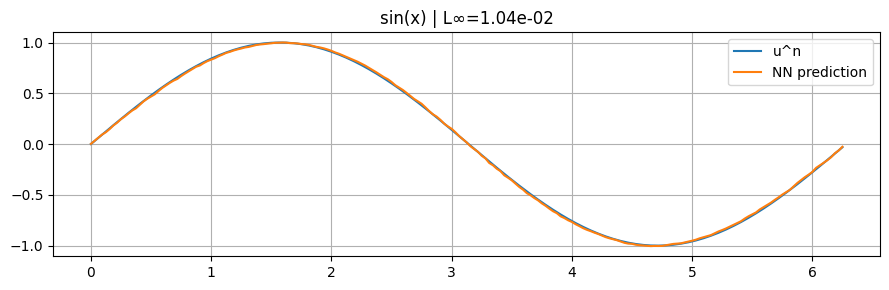

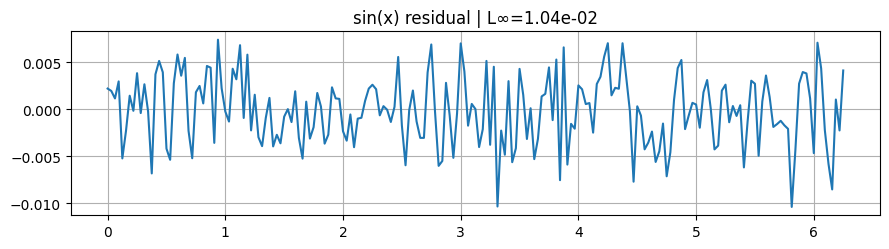

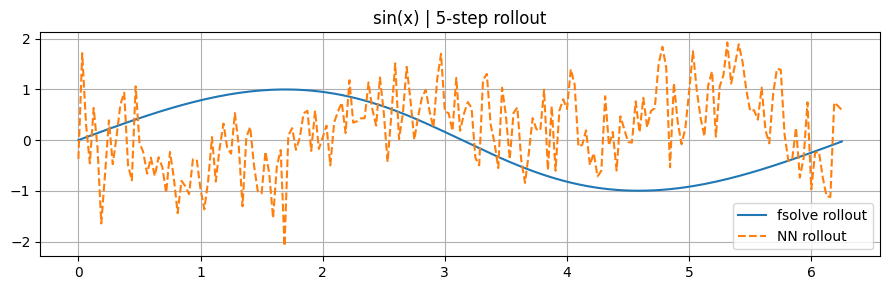


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=2.783e-01 | Mean=9.079e-02
NN inference : 10.579 ms
fsolve solve : 23.160 ms
5-step rollout: 0.037 sec
Memory usage : 1601.36 MB


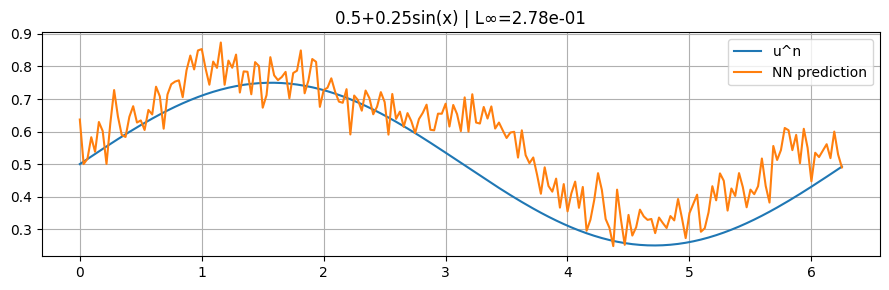

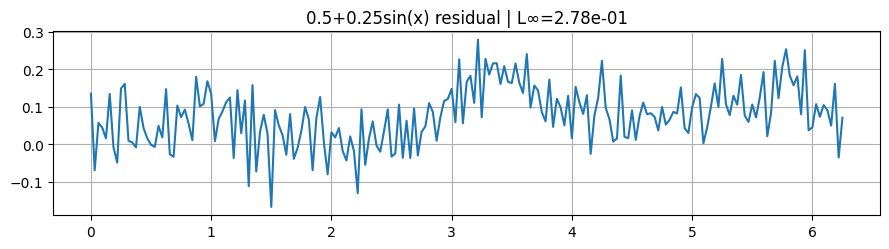

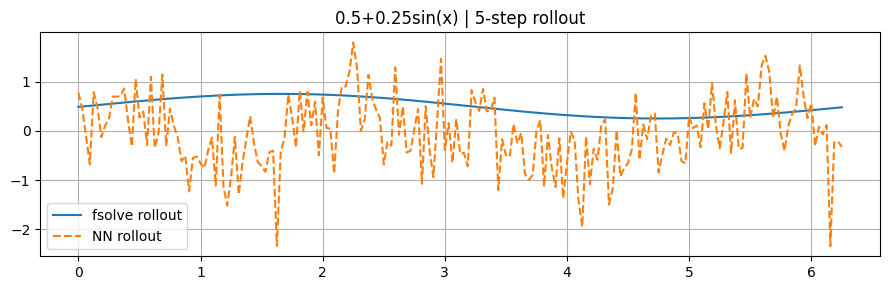


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=1.645e-01 | Mean=4.197e-02
NN inference : 11.877 ms
fsolve solve : 27.456 ms
5-step rollout: 0.036 sec
Memory usage : 1606.18 MB


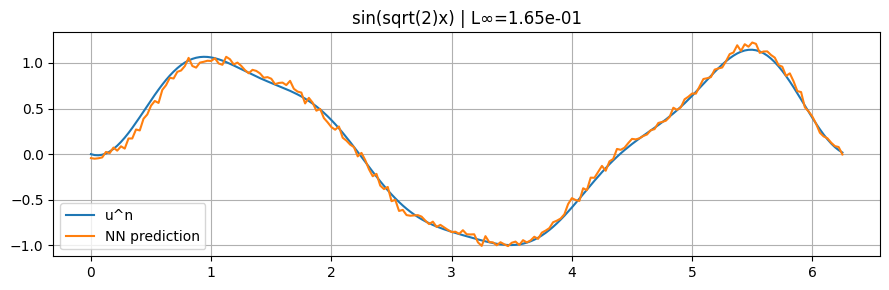

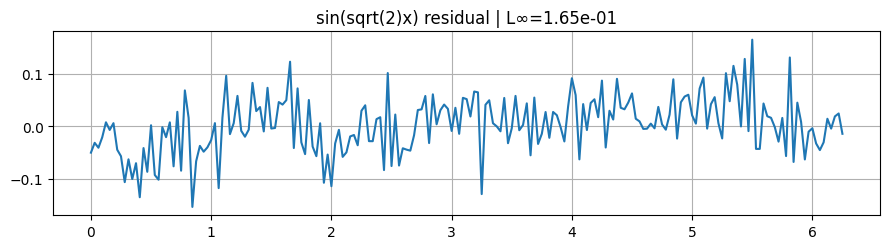

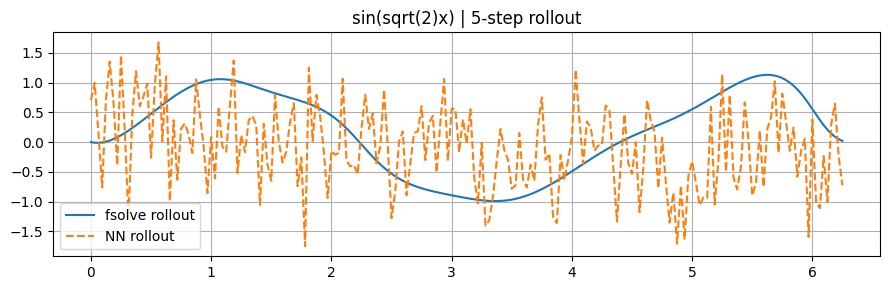


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=4.200e-01 | Mean=1.025e-01
NN inference : 10.845 ms
fsolve solve : 23.402 ms
5-step rollout: 0.048 sec
Memory usage : 1609.82 MB


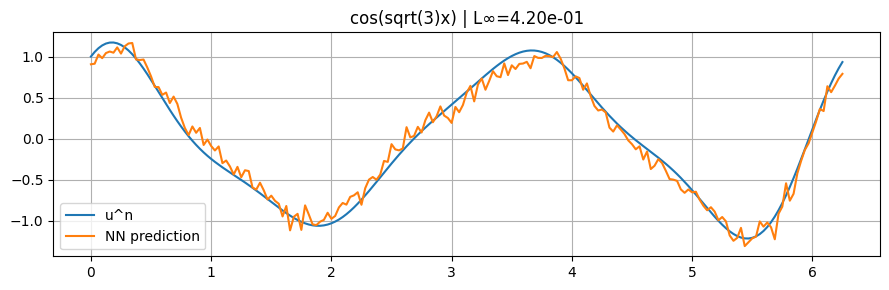

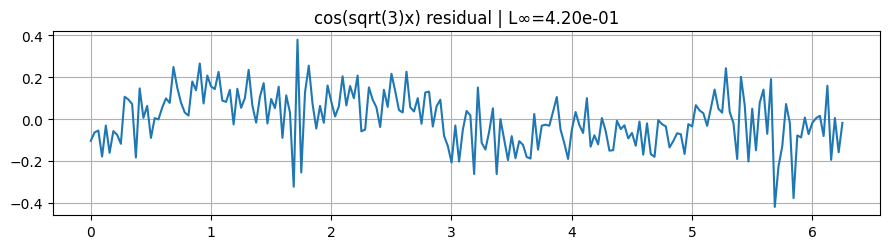

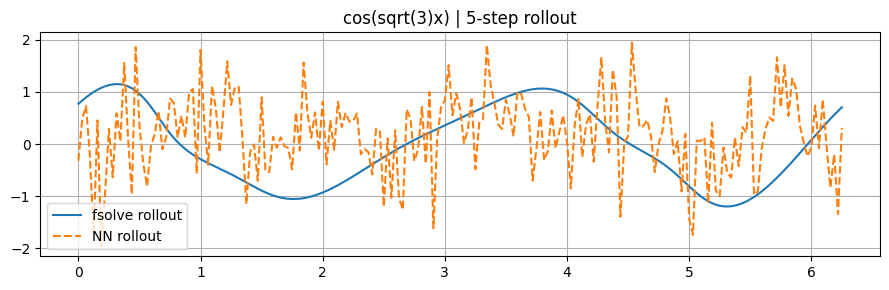


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=5.056e-01 | Mean=1.883e-01
NN inference : 15.265 ms
fsolve solve : 36.212 ms
5-step rollout: 0.059 sec
Memory usage : 1611.86 MB


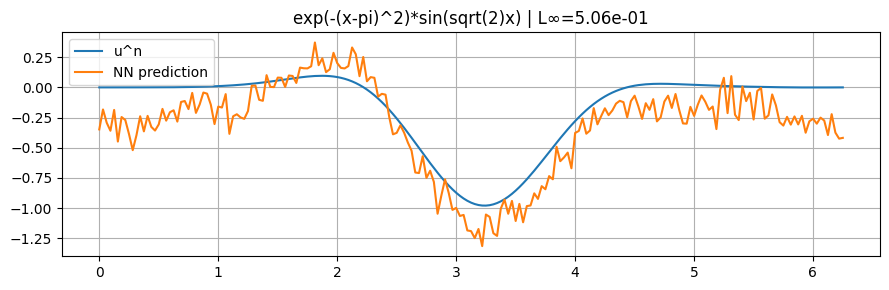

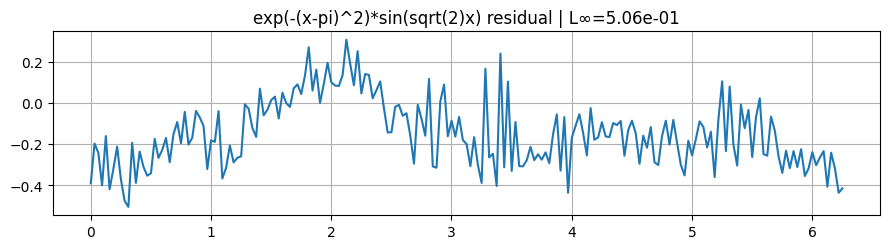

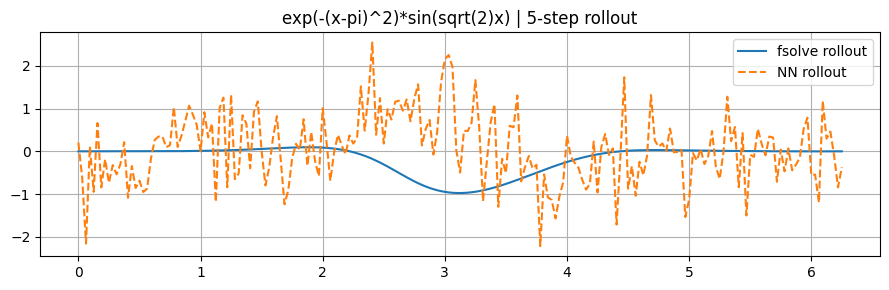


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=2.850e-01 | Mean=7.248e-02
NN inference : 14.687 ms
fsolve solve : 35.672 ms
5-step rollout: 0.056 sec
Memory usage : 1615.52 MB


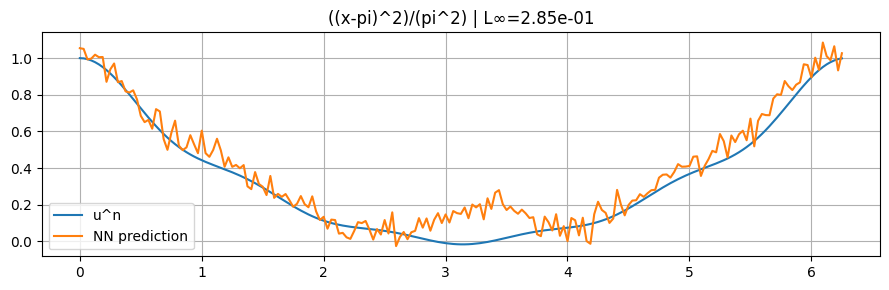

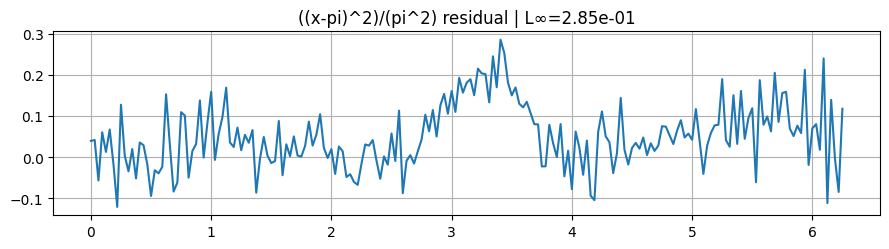

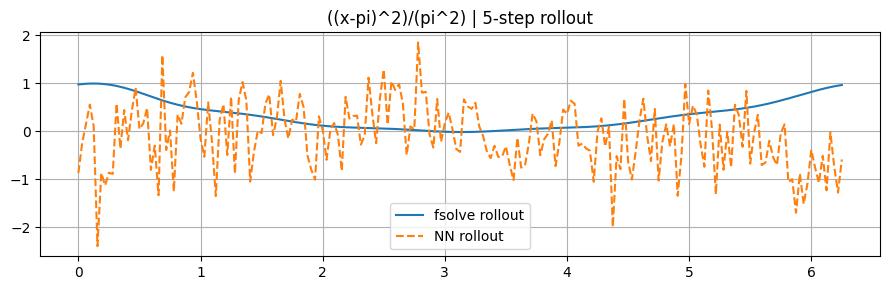


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=3.851e-01 | Mean=1.297e-01
NN inference : 12.920 ms
fsolve solve : 30.394 ms
5-step rollout: 0.068 sec
Memory usage : 1617.29 MB


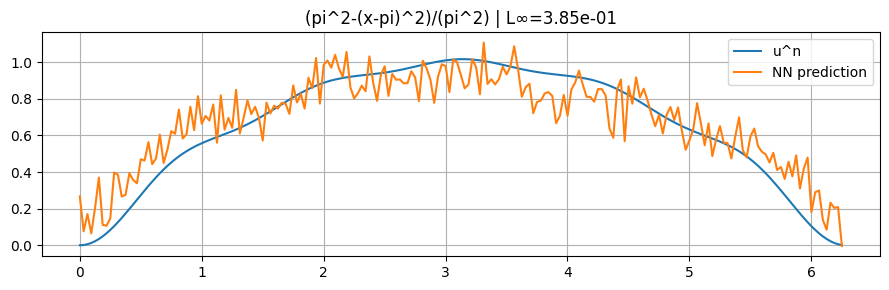

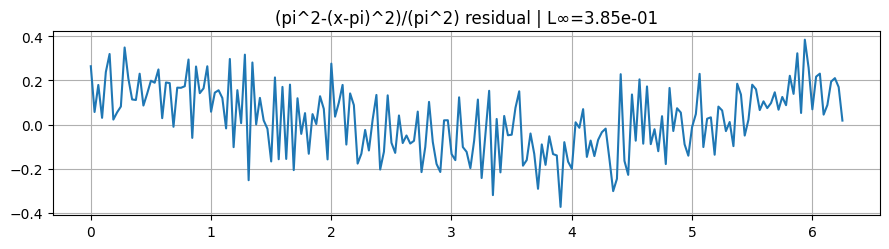

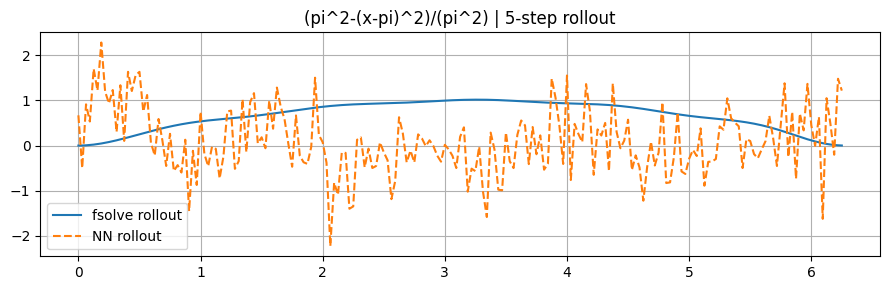


Saved summary CSV:
CaseB_PhysicsOnly_results\testing_summary.csv

Plots saved in:
CaseB_PhysicsOnly_results\plots


In [8]:
# TEST & DIAGNOSTICS

import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

# Paths
OUT_DIR = "CaseB_PhysicsOnly_results"

PLOTS_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly_meta.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary.csv"
)

# mempry
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# Loading meta
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])

NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])

L  = float(meta["L"])

HIDDEN_UNITS = int(meta["HIDDEN_UNITS"])

DEPTH = int(meta["DEPTH"])

SIREN_W0 = float(meta["SIREN_W0"])

feat_mean = meta["feat_mean"]

feat_std = meta["feat_std"]

# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Differentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

# Fourier interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left = pad_total // 2

    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12
    )

    return y_sol.astype(np.float64)

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# Safe filename
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# =========================================================
# ROLLOUT
# =========================================================

def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Testing functions
tests = [

    (
        "sin(x)",
        lambda x: np.sin(x)
    ),

    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),

    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),

    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x:
            np.exp(-(x - np.pi)**2)
            * np.sin(np.sqrt(2)*x)
    ),

    (
        "((x-pi)^2)/(pi^2)",
        lambda x:
            ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x:
            (np.pi**2 - (x - np.pi)**2)
            / (np.pi**2)
    )
]

summary = []

# Testing
print("\nTEST & DIAGNOSTICS")

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )
    # NN prediction timing
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # fsolve timing
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # residual
    r = residual_np(y_pred, uf)

    Linf = float(np.max(np.abs(r)))

    Mean = float(np.mean(np.abs(r)))

    # rollout timing
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Solution plot
    plt.figure(figsize=(9,3))

    plt.plot(xs, uf, label="u^n")

    plt.plot(xs, y_pred, label="NN prediction")

    plt.legend()

    plt.title(f"{name} | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(f"{name} residual | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()
    # Rolling oout plots
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(f"{name} | {steps}-step rollout")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ])

# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)

# Case2 for dt=0.005

In [1]:
# IMPORTS
import os
import time
import psutil
import random
import warnings
import csv

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve
from scipy.optimize import minimize

tf.config.set_visible_devices([], 'GPU')

# CONFIG
TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam
EPOCHS      = 1200
LR          = 2e-5

SUP_WEIGHT  = 0.0
PHYS_WEIGHT = 0.1 / DT

BETA_L2   = 1e-6
GRAD_CLIP = 0.5
PATIENCE  = 800

# L-BFGS
USE_LBFGS     = True
LBFGS_MAXITER = 300
LBFGS_FTOL    = 1e-10

# Output Paths
CASE_NAME = "CaseB_PhysicsOnly_0.005"

OUT_DIR = f"{CASE_NAME}_results"

os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly_meta_0.005.npz"
)

DATA_FILE = os.path.join(
    OUT_DIR,
    "training_pairs_0.005.npz"
)

METRICS_FILE = os.path.join(
    OUT_DIR,
    "timing_metrics_0.005.csv"
)

# Reproducibility
if TF64:

    tf.keras.backend.set_floatx("float64")

np.random.seed(42)

tf.random.set_seed(42)

random.seed(42)

warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

tf.get_logger().setLevel("ERROR")

# Memory utilities
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

print("\nCONFIG LOADED")

print("Initial memory usage: %.2f MB" % memory_mb())

# Spectral differentiation
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(
    D_np,
    dtype=tf.float64
)

# Residual
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(
        y_sq,
        tf.transpose(D_tf)
    )

    return y - u + 0.25 * DT * dy_dx

# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Fourier interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2

    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(
        un,
        dtype=np.float64
    )

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol, info, ier, msg = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12,
        maxfev=30000,
        full_output=True
    )

    if ier != 1:

        print("[warn fsolve]", msg)

    return y_sol.astype(np.float64)

# Training functions
def make_rich_family():

    fns = []
    # Fourier modes
    for k in range(1, 13):

        fns.append((
            f"sin({k}x)",
            lambda x, kk=k: np.sin(kk*x)
        ))

        fns.append((
            f"cos({k}x)",
            lambda x, kk=k: np.cos(kk*x)
        ))

    # Phase shifted
    for k in range(1, 6):

        for phi in [0.3, 0.7, 1.2]:

            fns.append((
                f"sin({k}x+{phi})",
                lambda x, kk=k, pp=phi:
                    np.sin(kk*x + pp)
            ))

    # Fractional frequencies
    for k in [1.5, 2.5, 3.5, 4.5]:

        fns.append((
            f"sin({k}x)",
            lambda x, kk=k: np.sin(kk*x)
        ))

    # Polynomial nonlinearities
    fns += [

        (
            "sin^2(x)",
            lambda x: np.sin(x)**2
        ),

        (
            "cos^2(x)",
            lambda x: np.cos(x)**2
        ),

        (
            "sin^3(x)",
            lambda x: np.sin(x)**3
        ),

        (
            "cos^3(x)",
            lambda x: np.cos(x)**3
        )
    ]
    # Mixed modes
    fns += [

        (
            "sin+0.5sin2",
            lambda x: np.sin(x)+0.5*np.sin(2*x)
        ),

        (
            "cos+0.5cos2",
            lambda x: np.cos(x)+0.5*np.cos(2*x)
        ),

        (
            "sin2+cos3",
            lambda x: np.sin(2*x)+np.cos(3*x)
        ),

        (
            "sin3+cos5",
            lambda x: np.sin(3*x)+0.7*np.cos(5*x)
        ),

        (
            "sin5+sin7",
            lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)
        ),

        (
            "cos4+cos8",
            lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)
        )
    ]

    # Gaussian-localized
    fns += [

        (
            "gauss*sin(5x)",
            lambda x:
                np.exp(-(x-np.pi)**2)
                * np.sin(5*x)
        ),

        (
            "gauss*sin(10x)",
            lambda x:
                np.exp(-(x-np.pi)**2)
                * np.sin(10*x)
        ),

        (
            "gauss*cos(7x)",
            lambda x:
                np.exp(-0.5*(x-np.pi)**2)
                * np.cos(7*x)
        )
    ]

    # Exponentials
    fns += [

        (
            "exp(-x)sin(x)",
            lambda x:
                np.exp(-0.2*x)*np.sin(x)
        ),

        (
            "exp(-x)cos(3x)",
            lambda x:
                np.exp(-0.4*x)*np.cos(3*x)
        )
    ]
    # Random combo
    rng = np.random.default_rng(123)

    for idx in range(30):

        ks = rng.integers(
            1,
            13,
            size=3
        )

        a = rng.uniform(
            -1.0,
            1.0,
            size=3
        )

        b = rng.uniform(
            -1.0,
            1.0,
            size=3
        )

        def make_fn(
            ks=ks,
            a=a,
            b=b
        ):

            return lambda x, ks=ks, a=a, b=b: (

                a[0]*np.sin(ks[0]*x)

                + a[1]*np.cos(ks[1]*x)

                + a[2]*np.sin(ks[2]*x)

                + b[0]*np.cos(ks[0]*x)

                + b[1]*np.sin(ks[1]*x)

                + b[2]*np.cos(ks[2]*x)
            )

        fns.append((
            f"rand_combo_{idx}",
            make_fn()
        ))

    return fns

train_fns = make_rich_family()

print(
    "Training family size:",
    len(train_fns)
)

# Generate / Load data
if os.path.exists(DATA_FILE):

    dd = np.load(
        DATA_FILE,
        allow_pickle=True
    )

    un_train = dd["un"]

    y1_train = dd["y1"]

    print(
        "Loaded cached data:",
        un_train.shape
    )

else:

    print("\nGenerating fsolve training data...")

    U_list = []

    Y_list = []

    for i, (name, fn) in enumerate(train_fns):

        u_c = fn(x_coarse)

        u_f = fourier_interpolate(
            u_c,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(u_f)

        U_list.append(u_f)

        Y_list.append(y1)

        print(
            f"{i+1}/{len(train_fns)} -> {name}"
        )

    un_train = np.array(U_list)

    y1_train = np.array(Y_list)

    np.savez(
        DATA_FILE,
        un=un_train,
        y1=y1_train
    )

# FEATURES
def build_features(un_batch):

    mag = np.abs(
        np.fft.fft(
            un_batch,
            axis=-1
        )
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate(
        [un_batch, mag],
        axis=-1
    )

X_raw = build_features(un_train)

feat_mean = np.mean(
    X_raw,
    axis=0
)

feat_std = np.std(
    X_raw,
    axis=0
) + 1e-12

X_norm = (
    X_raw - feat_mean
) / feat_std

print(
    "\nFeature shape:",
    X_norm.shape
)

# SIREN LAYER
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0 / in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Mpdel
def build_model():

    input_dim = X_norm.shape[1]

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(
        inputs,
        outputs
    )

model = build_model()

_ = model(
    tf.zeros(
        (1, X_norm.shape[1]),
        dtype=tf.float64
    )
)

print(
    model.count_params(),
    "parameters"
)

# Into tensors
X_tf = tf.convert_to_tensor(
    X_norm,
    dtype=tf.float64
)

U_tf = tf.convert_to_tensor(
    un_train,
    dtype=tf.float64
)

optimizer = tf.keras.optimizers.Adam(LR)

# Training
print("\nSTART TRAINING")

train_start = time.perf_counter()

peak_memory_before = memory_mb()

best_total = np.inf

wait = 0

for epoch in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y_pred = model(
            X_tf,
            training=True
        )
        # Phy loss only
        r = residual_tf(
            y_pred,
            U_tf
        )

        phys_loss = tf.reduce_mean(
            tf.square(r)
        )

        reg = BETA_L2 * tf.add_n([

            tf.nn.l2_loss(v)

            for v in model.trainable_variables
        ])

        total = (
            PHYS_WEIGHT * phys_loss
            + reg
        )

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [

        tf.clip_by_norm(g, GRAD_CLIP)

        for g in grads
    ]

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if epoch % 100 == 0 or epoch == 1:

        print(

            f"Epoch {epoch:4d} | "

            f"Total={float(total):.3e} | "

            f"Phys={float(phys_loss):.3e}"
        )

    total_val = float(total.numpy())

    if total_val < best_total:

        best_total = total_val

        wait = 0

        model.save_weights(
            WEIGHTS_FILE
        )

    else:

        wait += 1

        if wait >= PATIENCE:

            print("Early stopping.")

            break

train_end = time.perf_counter()

train_time_sec = (
    train_end - train_start
)

peak_memory_after = memory_mb()

peak_memory_used = (
    peak_memory_after
    - peak_memory_before
)

print("\nTRAINING COMPLETE")

print(
    "Training time: %.2f sec"
    % train_time_sec
)

print(
    "Memory increase: %.2f MB"
    % peak_memory_used
)

# L-BFGS polish
if USE_LBFGS:

    print(
        "\n=== PHASE 2: L-BFGS polish "
        "(physics-only loss) ==="
    )
    # reload best Adam weights
    model.load_weights(
        WEIGHTS_FILE
    )

    print(
        "[L-BFGS] loaded best Adam weights"
    )
    # parameter
    var_list = model.trainable_variables

    shapes = [v.shape for v in var_list]

    sizes = [
        int(np.prod(s))
        for s in shapes
    ]

    total_params = sum(sizes)

    print(
        "[L-BFGS] total params =",
        total_params
    )
    # pack weights
    def pack_weights():

        return np.concatenate([

            v.numpy().ravel()

            for v in var_list
        ])
    # unpack weights
    def unpack_weights(theta):

        offset = 0

        for v, s, sz in zip(
            var_list,
            shapes,
            sizes
        ):

            chunk = theta[
                offset:offset+sz
            ]

            v.assign(
                chunk.reshape(s)
            )

            offset += sz

    # loss
    @tf.function
    def loss_and_grads_tf():

        with tf.GradientTape() as tape:

            y_pred = model(
                X_tf,
                training=True
            )

            r = residual_tf(
                y_pred,
                U_tf
            )

            phys_loss = tf.reduce_mean(
                tf.square(r)
            )

            reg = BETA_L2 * tf.add_n([

                tf.nn.l2_loss(v)

                for v in model.trainable_variables
            ])

            total = (
                PHYS_WEIGHT * phys_loss
                + reg
            )

        grads = tape.gradient(
            total,
            var_list
        )

        return (
            total,
            grads,
            phys_loss
        )
    # scipy objective
    def lbfgs_objective(theta):

        unpack_weights(theta)

        total_tf, grads_tf, phys_tf = (
            loss_and_grads_tf()
        )

        loss_val = float(
            total_tf.numpy()
        )

        grad_vec = np.concatenate([

            g.numpy().ravel()

            for g in grads_tf
        ])

        return loss_val, grad_vec
        
    # initial weights
    theta0 = pack_weights()
    
    # timing start
    lbfgs_start = time.perf_counter()

    # optimization
    result = minimize(

        lbfgs_objective,

        theta0,

        jac=True,

        method='L-BFGS-B',

        options={

            'maxiter': LBFGS_MAXITER,

            'ftol': LBFGS_FTOL,

            'maxcor': 50,

            'iprint': 1
        }
    )
    # timing end
    lbfgs_end = time.perf_counter()

    lbfgs_time = (
        lbfgs_end - lbfgs_start
    )

    print(
        "\n[L-BFGS] optimization finished"
    )

    print(
        "[L-BFGS] time: %.2f sec"
        % lbfgs_time
    )

    print(
        "[L-BFGS] success:",
        result.success
    )

    print(
        "[L-BFGS] message:",
        result.message
    )

    # restore optimized weights
    unpack_weights(result.x)

    # final losses
    total_tf, _, phys_tf = (
        loss_and_grads_tf()
    )

    print("\n[L-BFGS FINAL]")

    print(
        "Total = %.3e"
        % float(total_tf.numpy())
    )

    print(
        "Phys  = %.3e"
        % float(phys_tf.numpy())
    )

    # save polished weights
    model.save_weights(
        WEIGHTS_FILE
    )

    print(
        "\n[L-BFGS] saved polished weights:"
    )

    print(WEIGHTS_FILE)

    
# SAVE META
np.savez(

    META_FILE,

    feat_mean=feat_mean,

    feat_std=feat_std,

    NX_FINE=NX_FINE,

    NX_COARSE=NX_COARSE,

    DT=DT,

    L=L,

    HIDDEN_UNITS=HIDDEN_UNITS,

    DEPTH=DEPTH,

    SIREN_W0=SIREN_W0
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE)


CONFIG LOADED
Initial memory usage: 356.33 MB
Training family size: 88

Generating fsolve training data...
1/88 -> sin(1x)
2/88 -> cos(1x)
3/88 -> sin(2x)
4/88 -> cos(2x)
5/88 -> sin(3x)
6/88 -> cos(3x)
7/88 -> sin(4x)
8/88 -> cos(4x)
9/88 -> sin(5x)
10/88 -> cos(5x)
11/88 -> sin(6x)
12/88 -> cos(6x)
13/88 -> sin(7x)
14/88 -> cos(7x)
15/88 -> sin(8x)
16/88 -> cos(8x)
17/88 -> sin(9x)
18/88 -> cos(9x)
19/88 -> sin(10x)
20/88 -> cos(10x)
21/88 -> sin(11x)
22/88 -> cos(11x)
23/88 -> sin(12x)
24/88 -> cos(12x)
25/88 -> sin(1x+0.3)
26/88 -> sin(1x+0.7)
27/88 -> sin(1x+1.2)
28/88 -> sin(2x+0.3)
29/88 -> sin(2x+0.7)
30/88 -> sin(2x+1.2)
31/88 -> sin(3x+0.3)
32/88 -> sin(3x+0.7)
33/88 -> sin(3x+1.2)
34/88 -> sin(4x+0.3)
35/88 -> sin(4x+0.7)
36/88 -> sin(4x+1.2)
37/88 -> sin(5x+0.3)
38/88 -> sin(5x+0.7)
39/88 -> sin(5x+1.2)
40/88 -> sin(1.5x)
41/88 -> sin(2.5x)
42/88 -> sin(3.5x)
43/88 -> sin(4.5x)
44/88 -> sin^2(x)
45/88 -> cos^2(x)
46/88 -> sin^3(x)
47/88 -> cos^3(x)
48/88 -> sin+0.5sin2
49/

### Computational metrics

In [2]:
# LOAD SAVED MODEL
model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

model.load_weights(os.path.join(
    OUT_DIR,
    "caseB_physonly_0.005.weights.h5"
))

print("Loaded saved model.")

# Feature builder
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Test functions
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),

    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x:
            np.exp(-(x - np.pi)**2)
            * np.sin(np.sqrt(2)*x)
    ),
    # Normalized polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x:
            ((x - np.pi)**2)
    ),

    (
        "(pi^2-(x-pi)^2)",
        lambda x:
            (np.pi**2 - (x - np.pi)**2)
            
    )
]

# Metrics
rows = []

for name, fn in tests:

    print("\n====================")

    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )
    # SINGLE STEP NN
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Rollout
    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps=5)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # Residual
    r = residual_np(y_pred, uf)

    Linf = np.max(np.abs(r))

    Mean = np.mean(np.abs(r))

    # Memory
    mem_now = memory_mb()

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    print(f"Linf residual: {Linf:.3e}")

    rows.append([

        name,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now,

        Linf,

        Mean
    ])

# SAVE CSV
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB",

        "Linf",

        "MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")

print(METRICS_FILE)

Loaded saved model.

sin(x)
NN inference : 10.524 ms
fsolve solve : 42.479 ms
5-step rollout: 0.044 sec
Memory usage : 1600.67 MB
Linf residual: 1.040e-02

0.5+0.25sin(x)
NN inference : 8.821 ms
fsolve solve : 25.084 ms
5-step rollout: 0.047 sec
Memory usage : 1600.70 MB
Linf residual: 2.783e-01

sin(sqrt(2)x)
NN inference : 9.253 ms
fsolve solve : 29.338 ms
5-step rollout: 0.052 sec
Memory usage : 1600.75 MB
Linf residual: 1.645e-01

cos(sqrt(3)x)
NN inference : 8.606 ms
fsolve solve : 31.995 ms
5-step rollout: 0.051 sec
Memory usage : 1600.75 MB
Linf residual: 4.200e-01

exp(-(x-pi)^2)*sin(sqrt(2)x)
NN inference : 19.533 ms
fsolve solve : 31.576 ms
5-step rollout: 0.046 sec
Memory usage : 1600.79 MB
Linf residual: 5.056e-01

((x-pi)^2)/(pi^2)
NN inference : 7.149 ms
fsolve solve : 26.423 ms
5-step rollout: 0.036 sec
Memory usage : 1600.82 MB
Linf residual: 1.041e+01

(pi^2-(x-pi)^2)
NN inference : 5.781 ms
fsolve solve : 22.646 ms
5-step rollout: 0.033 sec
Memory usage : 1600.86 MB
L

### Testing


Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=1.040e-02 | Mean=2.985e-03
NN inference : 9.636 ms
fsolve solve : 27.012 ms
5-step rollout: 0.036 sec
Memory usage : 1588.23 MB


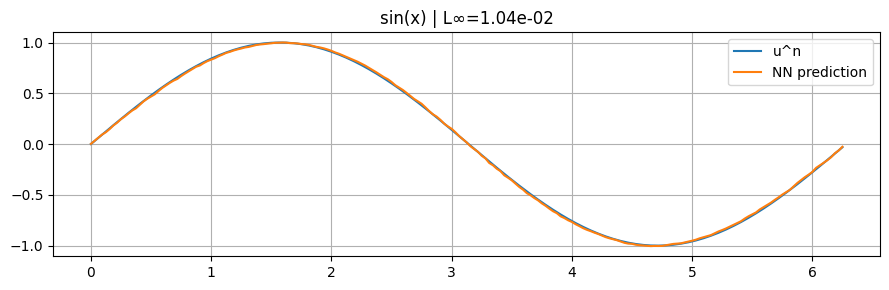

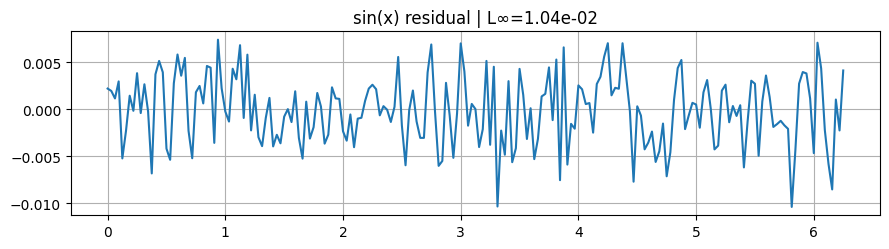

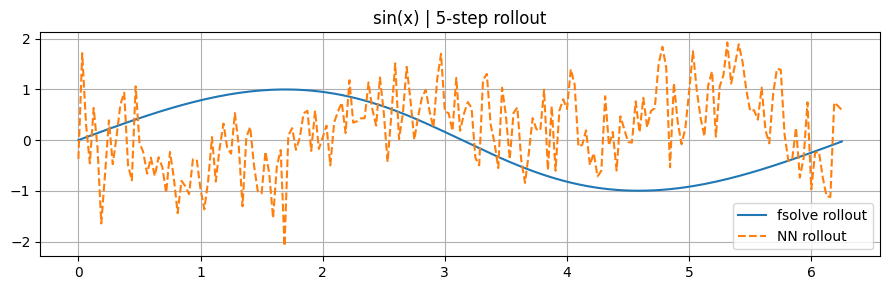


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=2.783e-01 | Mean=9.079e-02
NN inference : 6.508 ms
fsolve solve : 14.220 ms
5-step rollout: 0.022 sec
Memory usage : 1592.24 MB


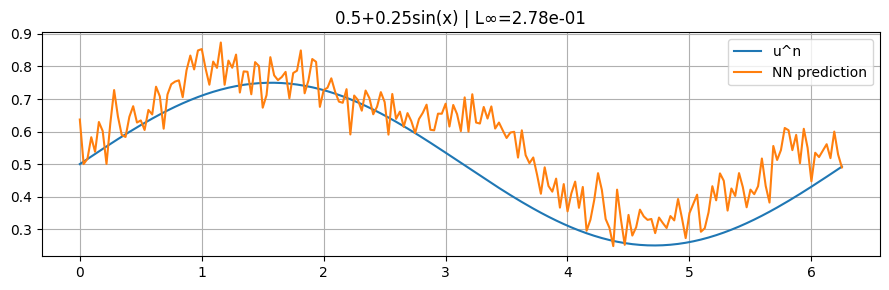

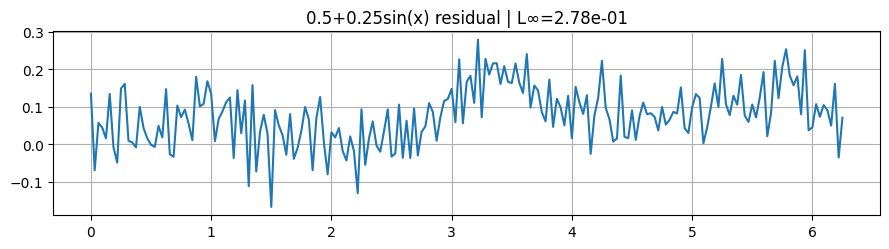

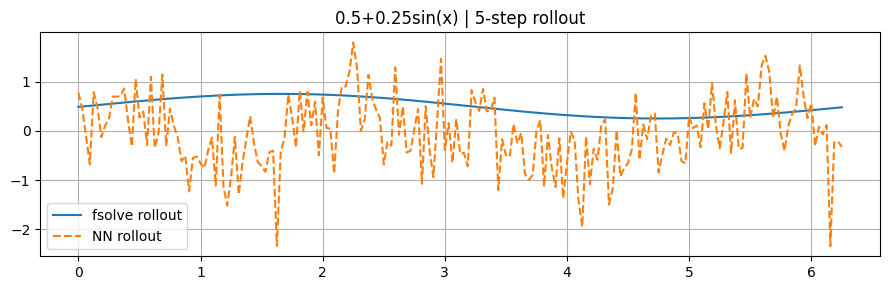


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=1.645e-01 | Mean=4.197e-02
NN inference : 10.892 ms
fsolve solve : 23.163 ms
5-step rollout: 0.024 sec
Memory usage : 1595.80 MB


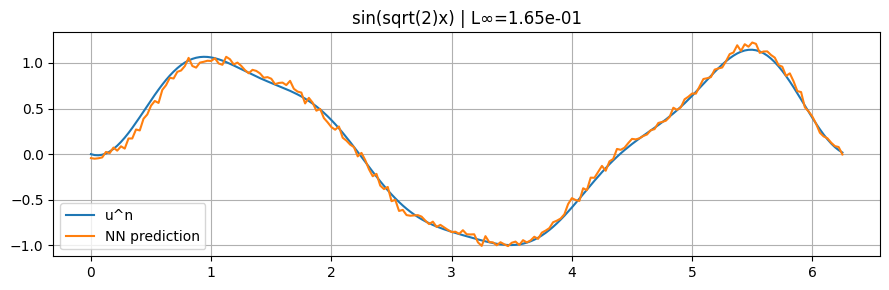

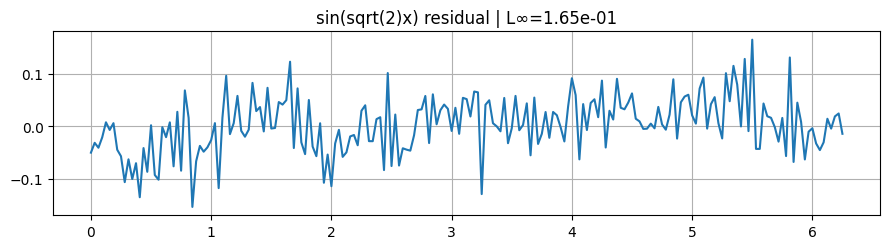

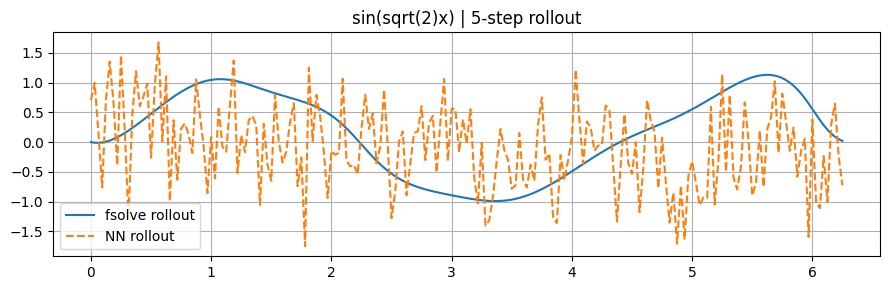


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=4.200e-01 | Mean=1.025e-01
NN inference : 28.274 ms
fsolve solve : 35.320 ms
5-step rollout: 0.054 sec
Memory usage : 1599.54 MB


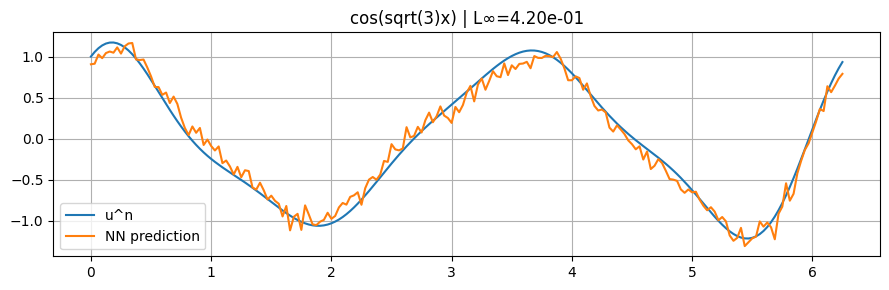

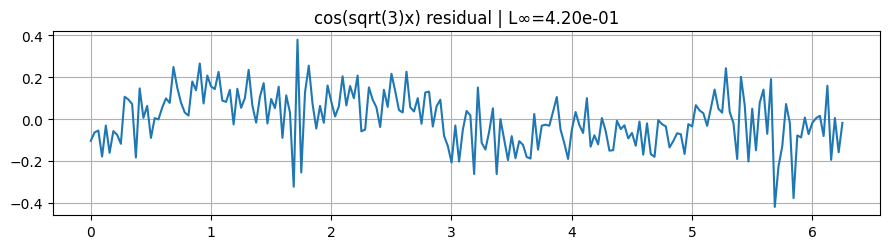

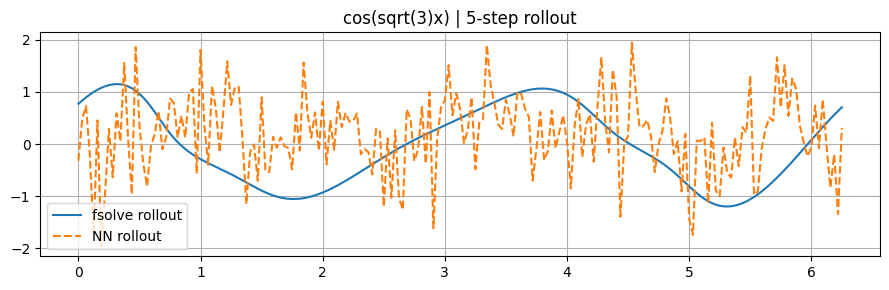


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=5.056e-01 | Mean=1.883e-01
NN inference : 7.280 ms
fsolve solve : 20.964 ms
5-step rollout: 0.028 sec
Memory usage : 1602.62 MB


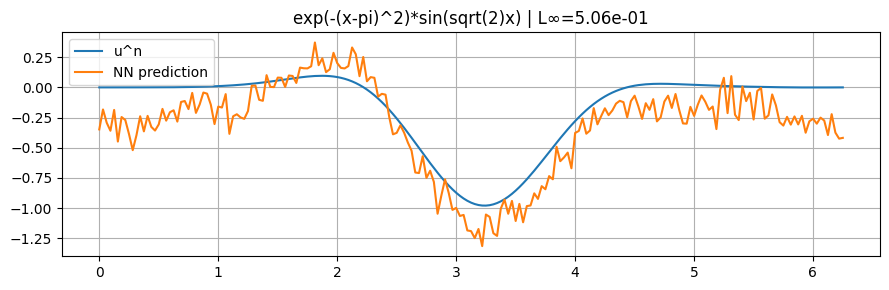

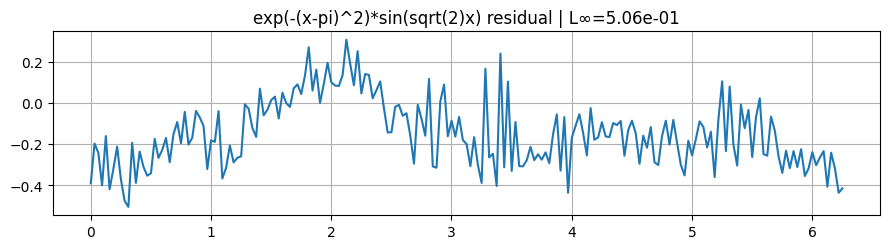

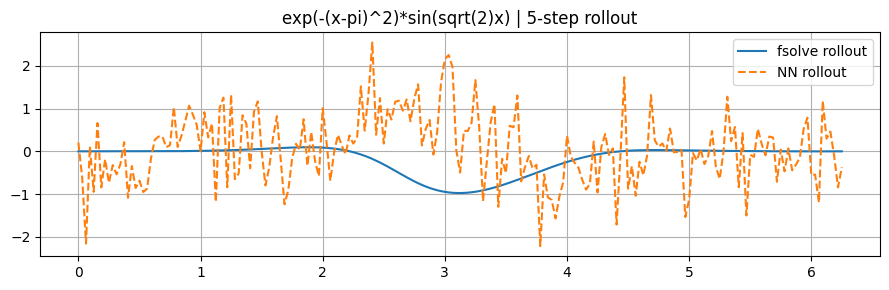


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=2.850e-01 | Mean=7.248e-02
NN inference : 7.740 ms
fsolve solve : 22.259 ms
5-step rollout: 0.041 sec
Memory usage : 1605.79 MB


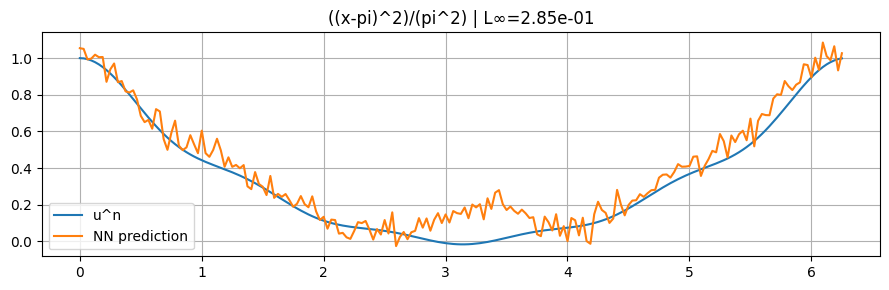

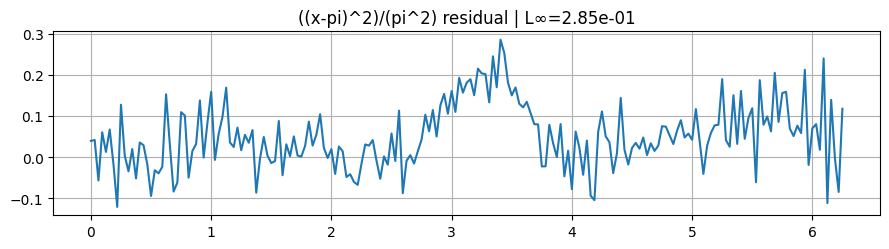

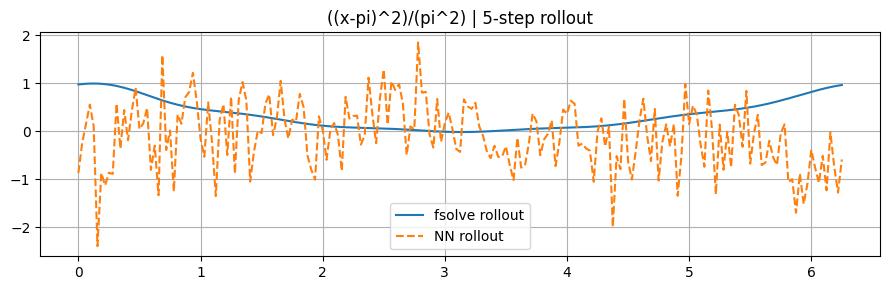


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=3.851e-01 | Mean=1.297e-01
NN inference : 8.835 ms
fsolve solve : 16.998 ms
5-step rollout: 0.033 sec
Memory usage : 1607.94 MB


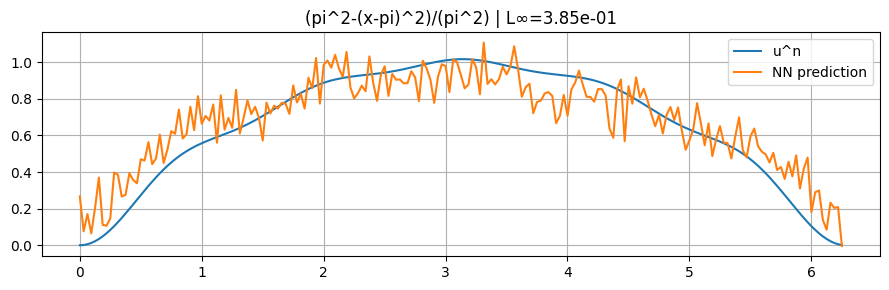

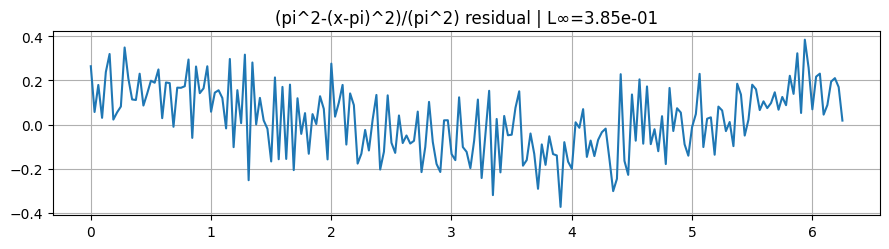

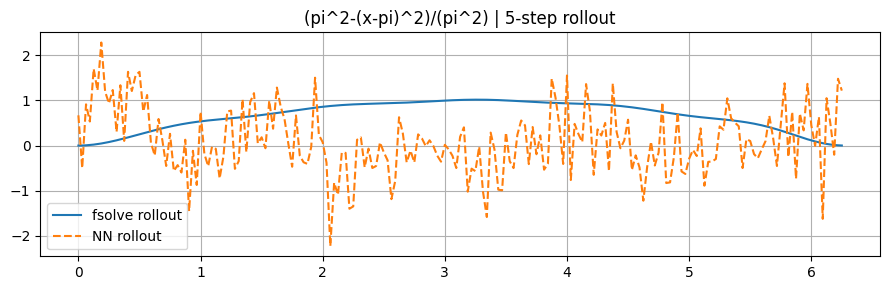


Saved summary CSV:
CaseB_PhysicsOnly_0.005_results\testing_summary_0.005.csv

Plots saved in:
CaseB_PhysicsOnly_0.005_results\plots


In [5]:
# Testing

import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

# Paths
OUT_DIR = "CaseB_PhysicsOnly_0.005_results"

PLOTS_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseB_physonly_meta_0.005.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary_0.005.csv"
)

# mempry
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# Loading meta
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])

NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])

L  = float(meta["L"])

HIDDEN_UNITS = int(meta["HIDDEN_UNITS"])

DEPTH = int(meta["DEPTH"])

SIREN_W0 = float(meta["SIREN_W0"])

feat_mean = meta["feat_mean"]

feat_std = meta["feat_std"]

# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Differentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

# Fourier interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left = pad_total // 2

    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12
    )

    return y_sol.astype(np.float64)

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# Safe filename
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout

def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Testing functions
tests = [

    (
        "sin(x)",
        lambda x: np.sin(x)
    ),

    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),

    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),

    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x:
            np.exp(-(x - np.pi)**2)
            * np.sin(np.sqrt(2)*x)
    ),

    (
        "((x-pi)^2)/(pi^2)",
        lambda x:
            ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x:
            (np.pi**2 - (x - np.pi)**2)
            / (np.pi**2)
    )
]

summary = []

# Testing
print("\nTEST & DIAGNOSTICS")

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )
    # NN prediction timing
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # fsolve timing
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # residual
    r = residual_np(y_pred, uf)

    Linf = float(np.max(np.abs(r)))

    Mean = float(np.mean(np.abs(r)))

    # rollout timing
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Solution plot
    plt.figure(figsize=(9,3))

    plt.plot(xs, uf, label="u^n")

    plt.plot(xs, y_pred, label="NN prediction")

    plt.legend()

    plt.title(f"{name} | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(f"{name} residual | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()
    # Rolling oout plots
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(f"{name} | {steps}-step rollout")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ])

# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)